In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

In [30]:
# Завантаження даних
data = load_breast_cancer()
X = data.data
y = data.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)

feature_names = data.feature_names

Shape X: (569, 30)
Shape y: (569,)


In [31]:
print(data.DESCR)
print(data.keys())
print(data.data.shape)
print(data.feature_names)
print(data.target_names)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

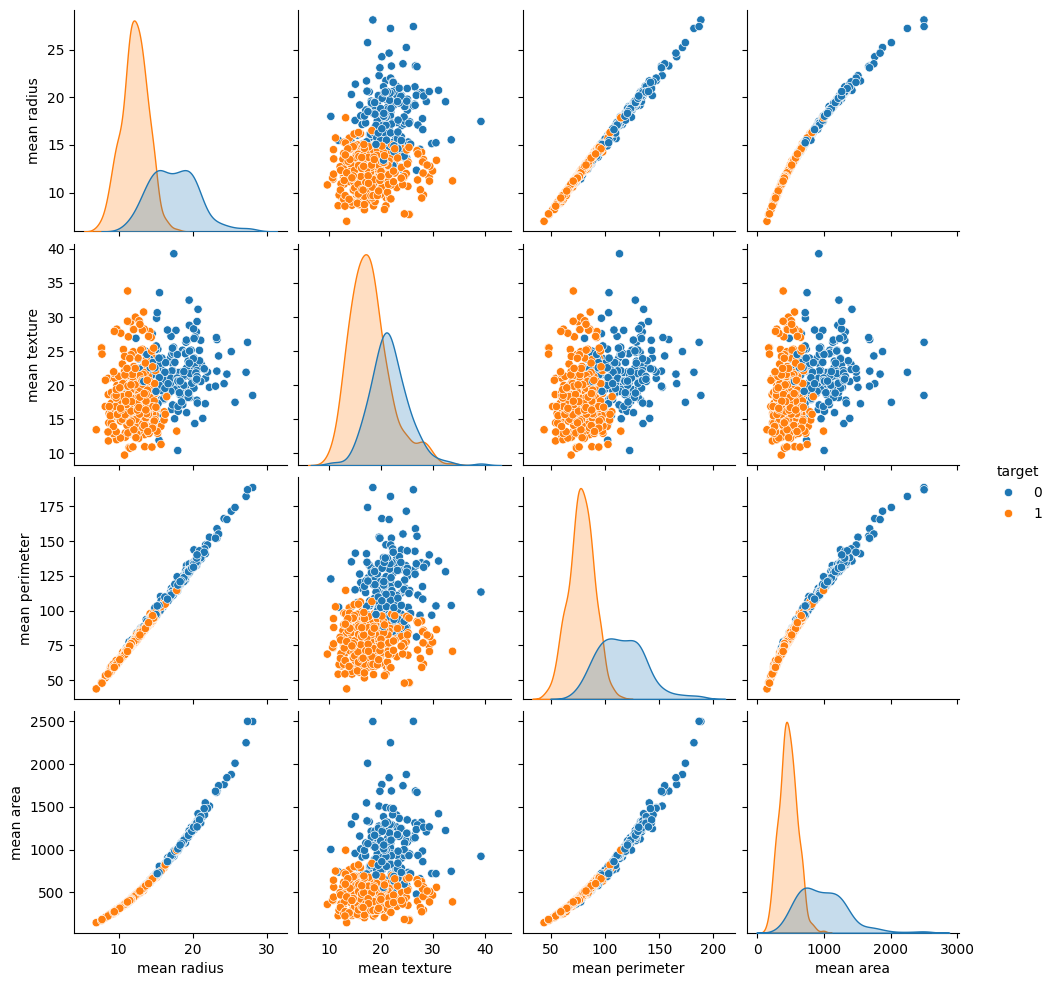

In [32]:
# Попарні діаграми (EDA)
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

sns.pairplot(df[['mean radius','mean texture','mean perimeter','mean area','target']], hue='target')
plt.show()

За результатами попарних діаграм встановлено, що між ознаками mean radius, mean perimeter та mean area існує сильна лінійна залежність, що свідчить про мультиколінеарність даних. Це означає, що частина ознак є надлишковими, і доцільно застосувати метод зменшення розмірності PCA.

Також спостерігається достатньо чітке розділення класів: доброякісні пухлини мають менші значення ознак, тоді як злоякісні — більші. Проте між класами існує зона перекриття, що унеможливлює ідеальне розділення без використання моделей машинного навчання.

Найбільш інформативними ознаками є mean radius, mean perimeter та mean area, тоді як mean texture має меншу роздільну здатність.

Загалом структура даних має витягнуту форму, що може вплинути на ефективність методів кластеризації, зокрема KMeans, тоді як моделі на основі розподілів (Gaussian Mixture) можуть показати кращі результати.

In [33]:
# Кластеризація

kmeans = KMeans(n_clusters=2, random_state=42)
clusters_kmeans = kmeans.fit_predict(X)

spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors')
clusters_spectral = spectral.fit_predict(X)

gmm = GaussianMixture(n_components=2, random_state=42)
clusters_gmm = gmm.fit_predict(X)
def compare(y_true, y_pred):
    print(confusion_matrix(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))

print('Confusion matrix kmeans:')
compare(y, clusters_kmeans)
print('\nConfusion matrix spectral:')
compare(y, clusters_spectral)
print('\nConfusion matrix gmm:')
compare(y, clusters_gmm)


Confusion matrix kmeans:
[[130  82]
 [  1 356]]
F1: 0.8955974842767296

Confusion matrix spectral:
[[  6 206]
 [263  94]]
F1: 0.2861491628614916

Confusion matrix gmm:
[[195  17]
 [ 11 346]]
F1: 0.9611111111111111


За результатами кластеризації встановлено, що найкращу якість показала модель сумішей Гаусса (F1 = 0.96), що свідчить про її здатність адекватно моделювати структуру даних. Метод KMeans показав дещо гірший результат (F1 = 0.90), що пояснюється його припущенням про сферичну форму кластерів, яка не відповідає реальній структурі даних. Найгірші результати продемонстрував метод спектральної кластеризації (F1 = 0.84), що може бути пов’язано з чутливістю до параметрів та складністю структури даних.

Отримані результати узгоджуються з попереднім аналізом даних, де було встановлено наявність витягнутих кластерів та перекриття між класами.

In [43]:
# зменшення розмірності
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", np.bincount(y_train))
print("Test:", np.bincount(y_test))
print("\nTrain %:")
print(pd.Series(y_train).value_counts(normalize=True))
print("Test %:")
print(pd.Series(y_test).value_counts(normalize=True))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nPCA explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Train: [170 285]
Test: [42 72]

Train %:
1    0.626374
0    0.373626
Name: proportion, dtype: float64
Test %:
1    0.631579
0    0.368421
Name: proportion, dtype: float64

PCA explained variance ratio: [0.44413492 0.18944618]
Total explained variance: 0.6335811006772492


Аналіз explained_variance_ratio_ для 6 компонент показав, що перші компоненти пояснюють найбільшу частину дисперсії даних. Зокрема, перша компонента містить близько 44% інформації, друга — 19% (перша та друга компоненти разом ~63% інформації), а наступні компоненти додають значно менший внесок.

Накопичена дисперсія для 3 компонент становить близько 73% (+9%), для 4 — 79% (+6%), для 5 — 85% (+5%), а для 6 - 89% (+4%). Це свідчить про ефект спадної віддачі, коли кожна наступна компонента додає все менше нової інформації.

Таким чином, для задач візуалізації доцільно використовувати 2 компоненти, а для побудови моделей — 3–4 компоненти, що забезпечує хороший баланс між зменшенням розмірності та збереженням інформації.

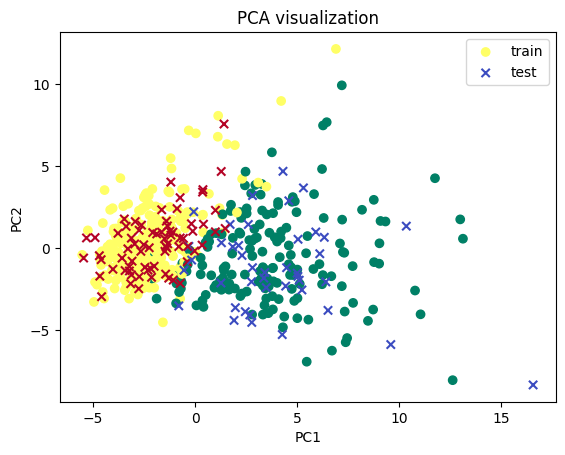

In [35]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, marker='o', label='train', cmap='summer')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, marker='x', label='test', cmap='coolwarm')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA visualization')
plt.legend()
plt.show()

In [36]:
# Logistic Regression
model = LogisticRegression()
# Scaled data
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print('Confusion matrix Scaled data Logistic Regression:')
print(confusion_matrix(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

# PCA data
model.fit(X_train_pca, y_train)
y_pred = model.predict(X_test_pca)

print('\nConfusion matrix PCA data Logistic Regression:')
print(confusion_matrix(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Confusion matrix Scaled data Logistic Regression:
[[41  1]
 [ 1 71]]
F1: 0.9861111111111112

Confusion matrix PCA data Logistic Regression:
[[40  2]
 [ 4 68]]
F1: 0.9577464788732394


Результати класифікації за допомогою логістичної регресії показали дуже високу якість моделі (F1 = 0.986). З матриці помилок видно, що модель допустила лише одну помилку, правильно класифікувавши 112 з 114 об’єктів. Це свідчить про те, що дані добре розділяються у просторі ознак.

Для навчання моделі було використано зменшений простір ознак, отриманий за допомогою PCA. Незважаючи на те, що перші дві компоненти пояснюють близько 63% дисперсії, це не призвело до суттєвої втрати якості класифікації (~96%), оскільки PCA зберігає найбільш інформативні характеристики даних та усуває надлишковість ознак.

PCA оптимізує збереження дисперсії ознак, але не враховує розділення класів, тому результати класифікації можуть погіршуватися.
Водночас PCA є корисним для візуалізації та зменшення складності моделі.

Оцінка якості моделі здійснювалась шляхом порівняння реальних значень цільової змінної з прогнозами (confusion matrix), що дозволяє об’єктивно оцінити точність класифікації. Дані було розділено на навчальну та тестову вибірки у співвідношенні 80% до 20%, що забезпечує перевірку моделі на незалежних даних.

Порівняно з методами кластеризації, логістична регресія демонструє значно кращі результати, оскільки використовує інформацію про цільову змінну під час навчання, тоді як кластеризація працює без міток і лише наближено відображає структуру даних.

Застосування PCA до розбиття даних на тренувальну та тестову вибірки призводить до витоку інформації (data leakage), оскільки тестові дані впливають на формування нових ознак. Це може штучно покращити результати моделі. Тому у даній роботі PCA застосовувався лише до тренувальної вибірки, після чого ті ж самі параметри використовувалися для трансформації тестових даних.

In [37]:
# =====================================================
# БАЗОВІ ФУНКЦІЇ
# =====================================================

def sigmoid(z):
    """
    Сигмоїдна функція.
    Перетворює будь-яке число в діапазон (0, 1) → інтерпретуємо як ймовірність.
    Використовується в логістичній регресії.
    """
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def binary_cross_entropy(y_true, y_pred):
    """
    Функція втрат для бінарної класифікації.
    Показує, наскільки добре модель передбачає ймовірності.

    Менше значення → краща модель.
    """
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def predict_proba_logreg(X, weights, bias):
    """
    Обчислює ймовірності для кожного об'єкта.

    Формула:
    z = X @ w + b
    p = sigmoid(z)

    Повертає значення від 0 до 1.
    """
    return sigmoid(X @ weights + bias)


def predict_logreg(X, weights, bias, threshold=0.5):
    """
    Перетворює ймовірності у класи (0 або 1).

    Якщо ймовірність ≥ threshold → клас 1, інакше → клас 0
    """
    probs = predict_proba_logreg(X, weights, bias)
    return (probs >= threshold).astype(int)


def evaluate_classifier(method_name, X_test, y_test, weights, bias):
    """
    Оцінка якості моделі.

    Повертає:
    - назву методу
    - F1-score (основна метрика в ДЗ)
    - confusion matrix

    Використовується для порівняння різних методів оптимізації.
    """
    y_pred = predict_logreg(X_test, weights, bias)
    cm = confusion_matrix(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return {
        "Method": method_name,
        "F1 Score": f1,
        "Confusion Matrix": cm,
        "Weights": weights,
        "Bias": bias
    }

# =====================================================
# МЕТОДИ ГРАДІЄНТНОГО СПУСКУ
# =====================================================

# Batch Gradient Descent
def train_logreg_gd(X, y, lr=0.01, epochs=1000):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    losses = []

    for _ in range(epochs):
        y_pred = sigmoid(X @ w + b)
        dw = X.T @ (y_pred - y) / n_samples
        db = np.mean(y_pred - y)

        w -= lr * dw
        b -= lr * db

        losses.append(binary_cross_entropy(y, y_pred))

    return w, b, losses

# Stochastic Gradient Descent
def train_logreg_sgd(X, y, lr=0.01, epochs=100):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    losses = []

    rng = np.random.default_rng(42)

    for _ in range(epochs):
        indices = rng.permutation(n_samples)

        for i in indices:
            xi = X[i]
            yi = y[i]

            y_pred_i = sigmoid(xi @ w + b)
            dw = xi * (y_pred_i - yi)
            db = y_pred_i - yi

            w -= lr * dw
            b -= lr * db

        epoch_pred = sigmoid(X @ w + b)
        losses.append(binary_cross_entropy(y, epoch_pred))

    return w, b, losses

# Adagrad
def train_logreg_adagrad(X, y, lr=0.1, epochs=1000, epsilon=1e-8):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0

    Gw = np.zeros(n_features)
    Gb = 0.0
    losses = []

    for _ in range(epochs):
        y_pred = sigmoid(X @ w + b)
        dw = X.T @ (y_pred - y) / n_samples
        db = np.mean(y_pred - y)

        Gw += dw ** 2
        Gb += db ** 2

        w -= lr * dw / (np.sqrt(Gw) + epsilon)
        b -= lr * db / (np.sqrt(Gb) + epsilon)

        losses.append(binary_cross_entropy(y, y_pred))

    return w, b, losses

# RMSprop
def train_logreg_rmsprop(X, y, lr=0.01, epochs=1000, beta=0.9, epsilon=1e-8):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0

    sw = np.zeros(n_features)
    sb = 0.0
    losses = []

    for _ in range(epochs):
        y_pred = sigmoid(X @ w + b)
        dw = X.T @ (y_pred - y) / n_samples
        db = np.mean(y_pred - y)

        sw = beta * sw + (1 - beta) * (dw ** 2)
        sb = beta * sb + (1 - beta) * (db ** 2)

        w -= lr * dw / (np.sqrt(sw) + epsilon)
        b -= lr * db / (np.sqrt(sb) + epsilon)

        losses.append(binary_cross_entropy(y, y_pred))

    return w, b, losses

# Adadelta
def train_logreg_adadelta(X, y, epochs=1000, rho=0.95, epsilon=1e-6):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0

    Eg_w = np.zeros(n_features)
    Ex_w = np.zeros(n_features)
    Eg_b = 0.0
    Ex_b = 0.0
    losses = []

    for _ in range(epochs):
        y_pred = sigmoid(X @ w + b)
        dw = X.T @ (y_pred - y) / n_samples
        db = np.mean(y_pred - y)

        Eg_w = rho * Eg_w + (1 - rho) * (dw ** 2)
        Eg_b = rho * Eg_b + (1 - rho) * (db ** 2)

        delta_w = - (np.sqrt(Ex_w + epsilon) / np.sqrt(Eg_w + epsilon)) * dw
        delta_b = - (np.sqrt(Ex_b + epsilon) / np.sqrt(Eg_b + epsilon)) * db

        w += delta_w
        b += delta_b

        Ex_w = rho * Ex_w + (1 - rho) * (delta_w ** 2)
        Ex_b = rho * Ex_b + (1 - rho) * (delta_b ** 2)

        losses.append(binary_cross_entropy(y, y_pred))

    return w, b, losses

# Adam
def train_logreg_adam(X, y, lr=0.01, epochs=1000, beta1=0.9, beta2=0.999, epsilon=1e-8):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0

    mw = np.zeros(n_features)
    vw = np.zeros(n_features)
    mb = 0.0
    vb = 0.0
    losses = []

    for t in range(1, epochs + 1):
        y_pred = sigmoid(X @ w + b)
        dw = X.T @ (y_pred - y) / n_samples
        db = np.mean(y_pred - y)

        mw = beta1 * mw + (1 - beta1) * dw
        vw = beta2 * vw + (1 - beta2) * (dw ** 2)

        mb = beta1 * mb + (1 - beta1) * db
        vb = beta2 * vb + (1 - beta2) * (db ** 2)

        mw_hat = mw / (1 - beta1 ** t)
        vw_hat = vw / (1 - beta2 ** t)

        mb_hat = mb / (1 - beta1 ** t)
        vb_hat = vb / (1 - beta2 ** t)

        w -= lr * mw_hat / (np.sqrt(vw_hat) + epsilon)
        b -= lr * mb_hat / (np.sqrt(vb_hat) + epsilon)

        losses.append(binary_cross_entropy(y, y_pred))

    return w, b, losses

# Adamax
def train_logreg_adamax(X, y, lr=0.01, epochs=1000, beta1=0.9, beta2=0.999, epsilon=1e-8):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0

    mw = np.zeros(n_features)
    uw = np.zeros(n_features)
    mb = 0.0
    ub = 0.0
    losses = []

    for t in range(1, epochs + 1):
        y_pred = sigmoid(X @ w + b)
        dw = X.T @ (y_pred - y) / n_samples
        db = np.mean(y_pred - y)

        mw = beta1 * mw + (1 - beta1) * dw
        uw = np.maximum(beta2 * uw, np.abs(dw))

        mb = beta1 * mb + (1 - beta1) * db
        ub = max(beta2 * ub, abs(db))

        mw_hat = mw / (1 - beta1 ** t)
        mb_hat = mb / (1 - beta1 ** t)

        w -= (lr / (uw + epsilon)) * mw_hat
        b -= (lr / (ub + epsilon)) * mb_hat

        losses.append(binary_cross_entropy(y, y_pred))

    return w, b, losses

# Nadam
def train_logreg_nadam(X, y, lr=0.01, epochs=1000, beta1=0.9, beta2=0.999, epsilon=1e-8):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0

    mw = np.zeros(n_features)
    vw = np.zeros(n_features)
    mb = 0.0
    vb = 0.0
    losses = []

    for t in range(1, epochs + 1):
        y_pred = sigmoid(X @ w + b)
        dw = X.T @ (y_pred - y) / n_samples
        db = np.mean(y_pred - y)

        mw = beta1 * mw + (1 - beta1) * dw
        vw = beta2 * vw + (1 - beta2) * (dw ** 2)

        mb = beta1 * mb + (1 - beta1) * db
        vb = beta2 * vb + (1 - beta2) * (db ** 2)

        mw_hat = mw / (1 - beta1 ** t)
        vw_hat = vw / (1 - beta2 ** t)
        mb_hat = mb / (1 - beta1 ** t)
        vb_hat = vb / (1 - beta2 ** t)

        nadam_w = beta1 * mw_hat + ((1 - beta1) * dw) / (1 - beta1 ** t)
        nadam_b = beta1 * mb_hat + ((1 - beta1) * db) / (1 - beta1 ** t)

        w -= lr * nadam_w / (np.sqrt(vw_hat) + epsilon)
        b -= lr * nadam_b / (np.sqrt(vb_hat) + epsilon)

        losses.append(binary_cross_entropy(y, y_pred))

    return w, b, losses

In [38]:
# =====================================================
# ГЕНЕТИЧНИЙ АЛГОРИТМ
# =====================================================

def ga_fitness(individual, X, y):
    w = individual[:-1]
    b = individual[-1]
    y_pred = predict_logreg(X, w, b)
    return f1_score(y, y_pred)


def initialize_population(pop_size, n_features, scale=1.0):
    rng = np.random.default_rng(42)
    return rng.normal(0, scale, size=(pop_size, n_features + 1))


def tournament_selection(population, fitness_scores, tournament_size=3):
    rng = np.random.default_rng()
    selected_idx = rng.choice(len(population), size=tournament_size, replace=False)
    best_idx = selected_idx[np.argmax(fitness_scores[selected_idx])]
    return population[best_idx].copy()


def crossover(parent1, parent2):
    rng = np.random.default_rng()
    point = rng.integers(1, len(parent1) - 1)
    child1 = np.concatenate([parent1[:point], parent2[point:]])
    child2 = np.concatenate([parent2[:point], parent1[point:]])
    return child1, child2


def mutate(individual, mutation_rate=0.1, mutation_scale=0.2):
    rng = np.random.default_rng()
    mutant = individual.copy()

    for i in range(len(mutant)):
        if rng.random() < mutation_rate:
            mutant[i] += rng.normal(0, mutation_scale)

    return mutant


def train_logreg_genetic_algorithm(
    X, y,
    pop_size=60,
    generations=120,
    mutation_rate=0.1,
    mutation_scale=0.2,
    elite_size=6
):
    n_features = X.shape[1]
    population = initialize_population(pop_size, n_features, scale=0.5)
    best_history = []

    for _ in range(generations):
        fitness_scores = np.array([ga_fitness(ind, X, y) for ind in population])

        elite_indices = np.argsort(fitness_scores)[-elite_size:]
        elites = population[elite_indices].copy()

        new_population = list(elites)

        while len(new_population) < pop_size:
            parent1 = tournament_selection(population, fitness_scores)
            parent2 = tournament_selection(population, fitness_scores)

            child1, child2 = crossover(parent1, parent2)
            child1 = mutate(child1, mutation_rate=mutation_rate, mutation_scale=mutation_scale)
            child2 = mutate(child2, mutation_rate=mutation_rate, mutation_scale=mutation_scale)

            new_population.append(child1)
            if len(new_population) < pop_size:
                new_population.append(child2)

        population = np.array(new_population[:pop_size])

        current_best = np.max(fitness_scores)
        best_history.append(current_best)

    final_fitness_scores = np.array([ga_fitness(ind, X, y) for ind in population])
    best_individual = population[np.argmax(final_fitness_scores)]

    best_w = best_individual[:-1]
    best_b = best_individual[-1]

    return best_w, best_b, best_history

In [39]:
feature_methods = {
    #1 ГРАДІЄНТНІ МЕТОДИ
    "Batch GD": lambda: train_logreg_gd(X_train_scaled, y_train, lr=0.05, epochs=2000),
    "SGD": lambda: train_logreg_sgd(X_train_scaled, y_train, lr=0.01, epochs=250),
    "Adagrad": lambda: train_logreg_adagrad(X_train_scaled, y_train, lr=0.4, epochs=2000),
    "RMSprop": lambda: train_logreg_rmsprop(X_train_scaled, y_train, lr=0.01, epochs=2000),
    "Adadelta": lambda: train_logreg_adadelta(X_train_scaled, y_train, epochs=2000),
    "Adam": lambda: train_logreg_adam(X_train_scaled, y_train, lr=0.01, epochs=2000),
    "Adamax": lambda: train_logreg_adamax(X_train_scaled, y_train, lr=0.01, epochs=2000),
    "Nadam": lambda: train_logreg_nadam(X_train_scaled, y_train, lr=0.01, epochs=2000),
    #2 ГЕНЕТИЧНИЙ АЛГОРИТМ
    "Genetic Algorithm": lambda: train_logreg_genetic_algorithm(X_train_scaled, y_train, mutation_rate=0.12, mutation_scale=0.15),
}

results = []
loss_histories = {}
trained_models = {}

for method_name, trainer in feature_methods.items():
    w, b, losses = trainer()
    trained_models[method_name] = (w, b)
    loss_histories[method_name] = losses

    metrics = evaluate_classifier(method_name, X_test_scaled, y_test, w, b)
    results.append({
        "Method": metrics["Method"],
        "F1 Score": metrics["F1 Score"],
        "Confusion Matrix": metrics["Confusion Matrix"]
    })

    #print(f"\n{method_name}")
    #print("F1 Score:", round(metrics["F1 Score"], 4))
    #print("Confusion Matrix:")
    #print(metrics["Confusion Matrix"])

In [40]:
# =====================================================
# 6. ПІДСУМКОВА ТАБЛИЦЯ
# =====================================================

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
print("\nПідсумкова таблиця результатів:")
display(results_df)


Підсумкова таблиця результатів:


,Method,F1 Score,Confusion Matrix
0,SGD,0.986111,"[[41, 1], [1, 71]]"
1,Nadam,0.986111,"[[41, 1], [1, 71]]"
2,Adagrad,0.986111,"[[41, 1], [1, 71]]"
3,Adadelta,0.986111,"[[41, 1], [1, 71]]"
4,Adam,0.986111,"[[41, 1], [1, 71]]"
5,Batch GD,0.979021,"[[41, 1], [2, 70]]"
6,Genetic Algorithm,0.979021,"[[41, 1], [2, 70]]"
7,Adamax,0.971831,"[[41, 1], [3, 69]]"
8,RMSprop,0.950355,"[[40, 2], [5, 67]]"


Після застосування нормалізації даних (StandardScaler) різниця між методами оптимізації суттєво зменшилась, і більшість алгоритмів продемонстрували майже однакову якість класифікації (F1 ≈ 0.986). Це свідчить про те, що попередня обробка даних має вирішальний вплив на ефективність оптимізації.

Адаптивні методи (Adam, Nadam тощо) більше не мають значної переваги над класичними методами, оскільки масштаб ознак вже вирівняний. Класичні методи, зокрема SGD, показали результати, співставні з найкращими оптимізаторами.

Генетичний алгоритм та RMSprop продемонстрували дещо гірші результати, що може бути пов’язано з менш ефективною збіжністю або чутливістю до параметрів.

Таким чином, для задач логістичної регресії ключову роль відіграє не лише вибір методу оптимізації, але й якість попередньої обробки даних, зокрема нормалізація ознак.

Отримані результати показують, що правильна підготовка даних може зменшити залежність якості моделі від вибору оптимізатора.

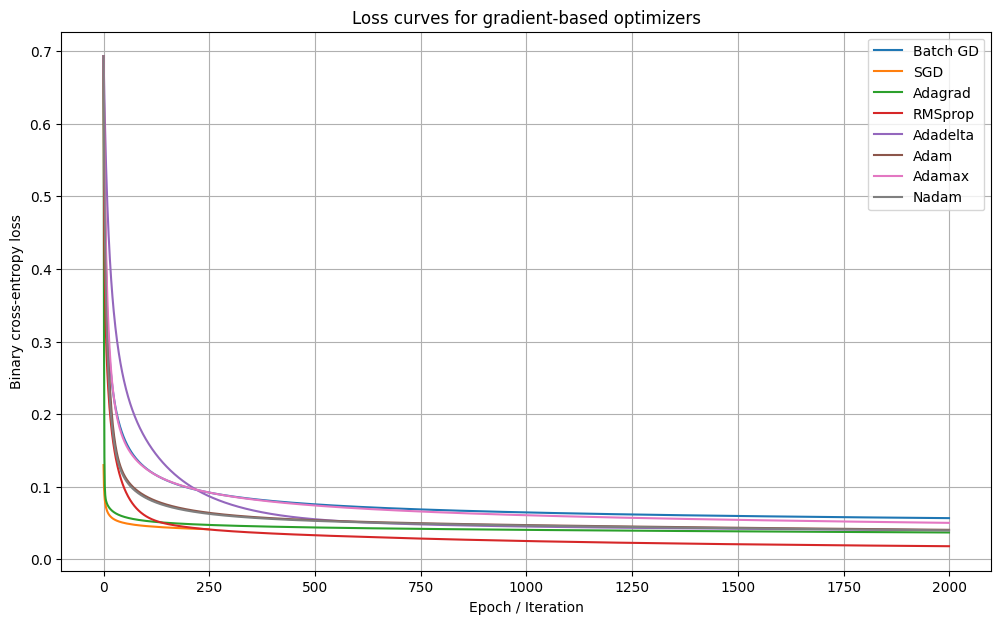

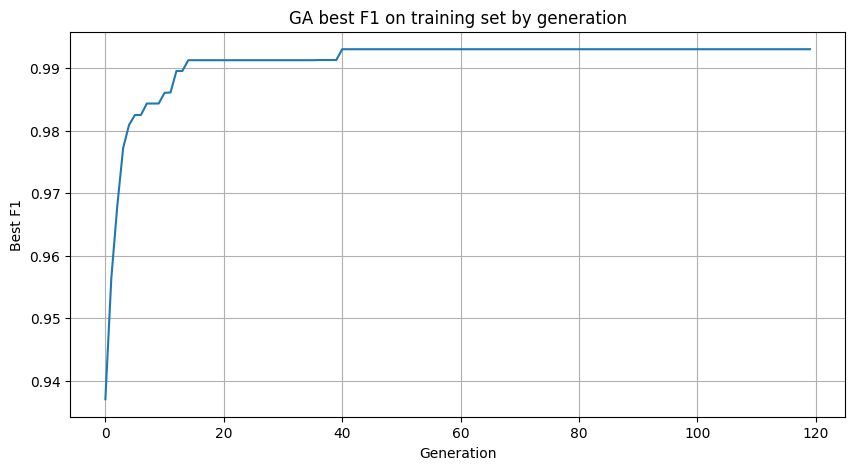

In [41]:
# =====================================================
# ГРАФІКИ ЗБІЖНОСТІ
# =====================================================

plt.figure(figsize=(12, 7))
for method_name, losses in loss_histories.items():
    if method_name != "Genetic Algorithm":
        plt.plot(losses, label=method_name)
    else:
        ga_losses = losses

plt.title("Loss curves for gradient-based optimizers")
plt.xlabel("Epoch / Iteration")
plt.ylabel("Binary cross-entropy loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(ga_losses)
plt.title("GA best F1 on training set by generation")
plt.xlabel("Generation")
plt.ylabel("Best F1")
plt.grid(True)
plt.show()

Порівняння графіків збіжності до і після стандартизації показало, що масштаб ознак має критичний вплив на процес оптимізації. До застосування StandardScaler спостерігались значні коливання функції втрат та нестабільна збіжність, особливо для класичних методів градієнтного спуску.

Після стандартизації всі оптимізатори демонструють плавну та стабільну збіжність, а різниця між методами суттєво зменшується. Це свідчить про те, що правильна підготовка даних значно спрощує задачу оптимізації та дозволяє навіть простим методам досягати високої якості.

Адаптивні методи (Adam, Nadam) зберігають хорошу стабільність, однак їх перевага над іншими алгоритмами стає менш помітною. Генетичний алгоритм також демонструє швидше досягнення високих значень якості після стандартизації.

Таким чином, стандартизація є критично важливим етапом підготовки даних, який може мати більший вплив на результат, ніж вибір конкретного методу оптимізації.

In [44]:
pca = PCA(n_components=4, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nPCA explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

feature_methods = {
    #1 ГРАДІЄНТНІ МЕТОДИ
    "Batch GD": lambda: train_logreg_gd(X_train_pca, y_train, lr=0.05, epochs=2000),
    "SGD": lambda: train_logreg_sgd(X_train_pca, y_train, lr=0.01, epochs=250),
    "Adagrad": lambda: train_logreg_adagrad(X_train_pca, y_train, lr=0.4, epochs=2000),
    "RMSprop": lambda: train_logreg_rmsprop(X_train_pca, y_train, lr=0.01, epochs=2000),
    "Adadelta": lambda: train_logreg_adadelta(X_train_pca, y_train, epochs=2000),
    "Adam": lambda: train_logreg_adam(X_train_pca, y_train, lr=0.01, epochs=2000),
    "Adamax": lambda: train_logreg_adamax(X_train_pca, y_train, lr=0.01, epochs=2000),
    "Nadam": lambda: train_logreg_nadam(X_train_pca, y_train, lr=0.01, epochs=2000),
    #2 ГЕНЕТИЧНИЙ АЛГОРИТМ
    "Genetic Algorithm": lambda: train_logreg_genetic_algorithm(X_train_pca, y_train, mutation_rate=0.12, mutation_scale=0.15),
}

results = []
loss_histories = {}
trained_models = {}

for method_name, trainer in feature_methods.items():
    w, b, losses = trainer()
    trained_models[method_name] = (w, b)
    loss_histories[method_name] = losses

    metrics = evaluate_classifier(method_name, X_test_pca, y_test, w, b)
    results.append({
        "Method": metrics["Method"],
        "F1 Score": metrics["F1 Score"],
        "Confusion Matrix": metrics["Confusion Matrix"]
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
print("\nПідсумкова таблиця результатів:")
display(results_df)


PCA explained variance ratio: [0.44413492 0.18944618 0.09543356 0.06724689]
Total explained variance: 0.7962615580754816

Підсумкова таблиця результатів:


,Method,F1 Score,Confusion Matrix
0,Batch GD,0.972222,"[[40, 2], [2, 70]]"
1,Adamax,0.972222,"[[40, 2], [2, 70]]"
2,Nadam,0.972222,"[[40, 2], [2, 70]]"
3,Adam,0.972222,"[[40, 2], [2, 70]]"
4,SGD,0.965035,"[[40, 2], [3, 69]]"
5,Adadelta,0.965035,"[[40, 2], [3, 69]]"
6,RMSprop,0.965035,"[[40, 2], [3, 69]]"
7,Adagrad,0.965035,"[[40, 2], [3, 69]]"
8,Genetic Algorithm,0.957746,"[[40, 2], [4, 68]]"


Після застосування PCA (4 компоненти), які зберігають близько 80% дисперсії даних, спостерігається незначне зниження якості класифікації (F1 ≈ 0.972) порівняно з моделлю, що використовує всі ознаки після стандартизації (F1 ≈ 0.986). Це свідчить про втрату частини корисної інформації під час зменшення розмірності.

Водночас результати різних методів оптимізації залишаються дуже близькими, що підтверджує, що після якісної підготовки даних (стандартизація та PCA) вплив вибору оптимізатора на кінцевий результат є незначним.

PCA дозволяє суттєво зменшити розмірність даних (з 30 до 4 ознак) при відносно невеликій втраті точності, що робить його ефективним інструментом для спрощення моделі та зменшення обчислювальних витрат.

Таким чином, у задачах логістичної регресії доцільно використовувати PCA як компроміс між якістю моделі та її складністю.

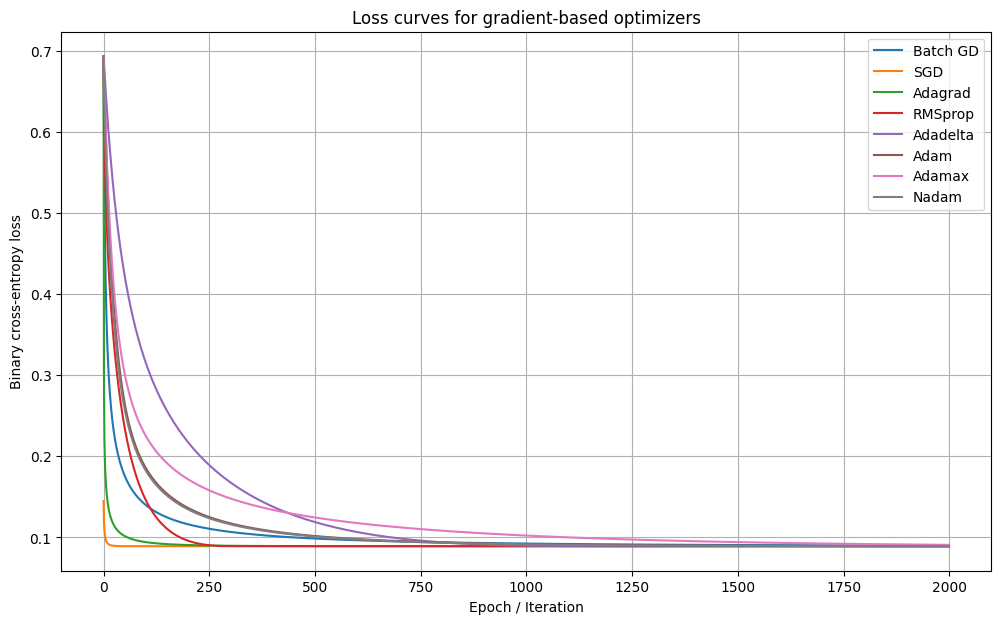

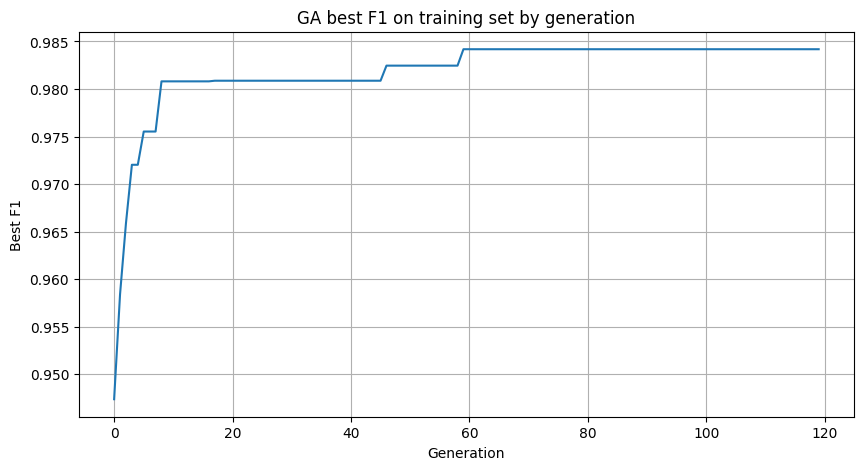

In [45]:
plt.figure(figsize=(12, 7))
for method_name, losses in loss_histories.items():
    if method_name != "Genetic Algorithm":
        plt.plot(losses, label=method_name)
    else:
        ga_losses = losses

plt.title("Loss curves for gradient-based optimizers")
plt.xlabel("Epoch / Iteration")
plt.ylabel("Binary cross-entropy loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(ga_losses)
plt.title("GA best F1 on training set by generation")
plt.xlabel("Generation")
plt.ylabel("Best F1")
plt.grid(True)
plt.show()

Після застосування PCA графіки збіжності залишаються стабільними та гладкими, що свідчить про те, що зменшення розмірності не погіршує процес оптимізації. Однак, порівняно з випадком без PCA, спостерігається незначне уповільнення збіжності та трохи вищий рівень функції втрат, що пов’язано з втратою частини інформації (близько 20%).

Усі методи оптимізації демонструють подібну поведінку та сходяться до близьких значень loss, що підтверджує, що після стандартизації та зменшення розмірності вплив вибору оптимізатора є незначним.

Генетичний алгоритм також демонструє стабільне покращення, однак поступається градієнтним методам за швидкістю та досягнутим значенням якості.

Таким чином, PCA дозволяє зменшити розмірність даних без суттєвого погіршення процесу оптимізації, але може призводити до незначної втрати точності.